In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cifar10_data_preprocessing import *

In [2]:
data_dir = 'cifar-10-batches-py'

# Load cifar-10 dataset.
train_data, train_labels, test_data, test_labels, label_names = load_data(data_dir)

# Shuffle the train_data and divide into train_data and dev_data.
# num_dev indicates the number of image data in dev set.
dev_data, dev_labels, train_data, train_labels = split_dataset(train_data, train_labels, num_dev = 5000)

# Check the shape of train/dev/test data and number of classes.
print("Train data: ", train_data.shape)
print("Train labels: ", train_labels.shape)
print("Dev data: ", dev_data.shape)
print("Dev labels: ", dev_labels.shape)
print("Test data: ", test_data.shape)
print("Test labels: ", test_labels.shape)
print('Number of classes:', label_names.shape[0])

Train data:  (45000, 32, 32, 3)
Train labels:  (45000,)
Dev data:  (5000, 32, 32, 3)
Dev labels:  (5000,)
Test data:  (10000, 32, 32, 3)
Test labels:  (10000,)
Number of classes: 10


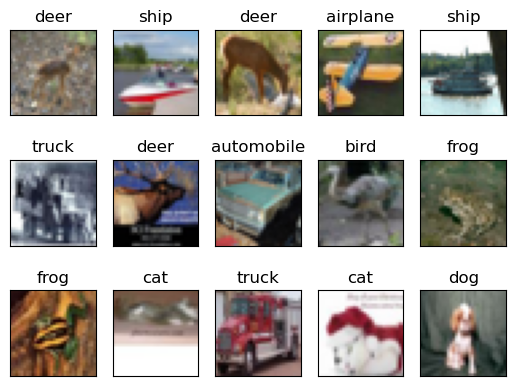

In [3]:
# Don't forget that the label_names and filesnames are in binary and need conversion if used.
classes = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# Display some random training images in a 3x5 grid
fig, ax = plt.subplots(3, 5)
for m in range(3):
    for n in range(5):
        idx = np.random.randint(0, train_data.shape[0])
        ax[m, n].set_title(classes[train_labels[idx]]) # display label
        ax[m, n].imshow(train_data[idx]) # display image data
        ax[m, n].get_xaxis().set_visible(False)
        ax[m, n].get_yaxis().set_visible(False)
plt.show()

In [4]:
# Convert label of each image data into one-hot vector(y). 
# Its length is the same as the number of classes.
y_train = one_hot_encoding(train_labels, classes)
y_dev = one_hot_encoding(dev_labels, classes)
y_test = one_hot_encoding(test_labels, classes)

print(y_train[0])
print(y_train.shape)


[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
(45000, 10)


In [5]:
# Normalize pixel values of input image from [0, 255] range to [0, 1] range.
x_train = normalize_image(train_data)
x_dev = normalize_image(dev_data)
x_test = normalize_image(test_data)

print(train_data[0]) # before normalization
print(x_train[0]) # after normalization

[[[134 124 126]
  [137 127 129]
  [142 132 134]
  ...
  [175 170 132]
  [173 168 130]
  [170 165 127]]

 [[136 126 123]
  [133 123 120]
  [127 117 114]
  ...
  [169 164 122]
  [169 164 122]
  [171 166 124]]

 [[139 129 119]
  [149 139 129]
  [151 141 131]
  ...
  [169 165 120]
  [170 166 120]
  [169 165 119]]

 ...

 [[171 157 126]
  [176 163 130]
  [175 164 128]
  ...
  [163 150 123]
  [149 136 107]
  [162 150 119]]

 [[174 159 128]
  [168 155 121]
  [163 153 117]
  ...
  [175 161 135]
  [175 161 135]
  [173 159 133]]

 [[166 150 120]
  [167 154 122]
  [164 153 118]
  ...
  [163 149 123]
  [173 159 133]
  [172 158 132]]]
[[[0.625      0.58139535 0.66242038]
  [0.64204545 0.59883721 0.68152866]
  [0.67045455 0.62790698 0.7133758 ]
  ...
  [0.85795455 0.84883721 0.70063694]
  [0.84659091 0.8372093  0.68789809]
  [0.82954545 0.81976744 0.66878981]]

 [[0.63636364 0.59302326 0.6433121 ]
  [0.61931818 0.5755814  0.62420382]
  [0.58522727 0.54069767 0.58598726]
  ...
  [0.82386364 0.8139534